<a href="https://colab.research.google.com/github/NIsik419/AI-assginment/blob/main/%5BAI2025_Assignment%5D_CIFAR10_Classification%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR10 Classification

## Import Packages

In [23]:
import sys
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Data Preparation
Use CIFAR10 handwriting dataset

In [24]:
cifar10 = tf.keras.datasets.cifar10

Prepare data for training

In [25]:
# train / test split
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# minmax normalization
x_train, x_test = x_train / 255.0, x_test / 255.0

# one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

# Compile and Train neural network

## CNN Modeling
Create a convolutional neural network

### Goal

Improve the provided basic CNN model and achieve CIFAR-10 **test accuracy ≥ 75%**.


Modify the network architecture!

In [26]:
model = tf.keras.models.Sequential([
    # First Conv Block - with padding to preserve spatial dimensions
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding='same', input_shape=(32, 32, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.3),

    # Second Conv Block
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.4),

    # Third Conv Block
    tf.keras.layers.Conv2D(256, (3, 3), activation="relu", padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3, 3), activation="relu", padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.5),

    # Flatten and Dense layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    # Output layer
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile and Train neural network

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

history = model.fit(
    x_train, y_train,
    epochs=30,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.2934 - loss: 2.2991 - val_accuracy: 0.3574 - val_loss: 2.0935 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5443 - loss: 1.2619 - val_accuracy: 0.5531 - val_loss: 1.2611 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6489 - loss: 0.9833 - val_accuracy: 0.6862 - val_loss: 0.9031 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7060 - loss: 0.8439 - val_accuracy: 0.7284 - val_loss: 0.7835 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7411 - loss: 0.7533 - val_accuracy: 0.7526 - val_loss: 0.7097 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7680 - loss: 0.6746 - val_accuracy: 0.7824 - val_loss: 0.6355 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7905 - l

## Evaluate neural network performance


313/313 - 2s - 6ms/step - accuracy: 0.8717 - loss: 0.4399

Test Accuracy: 87.17%
Test Loss: 0.4399



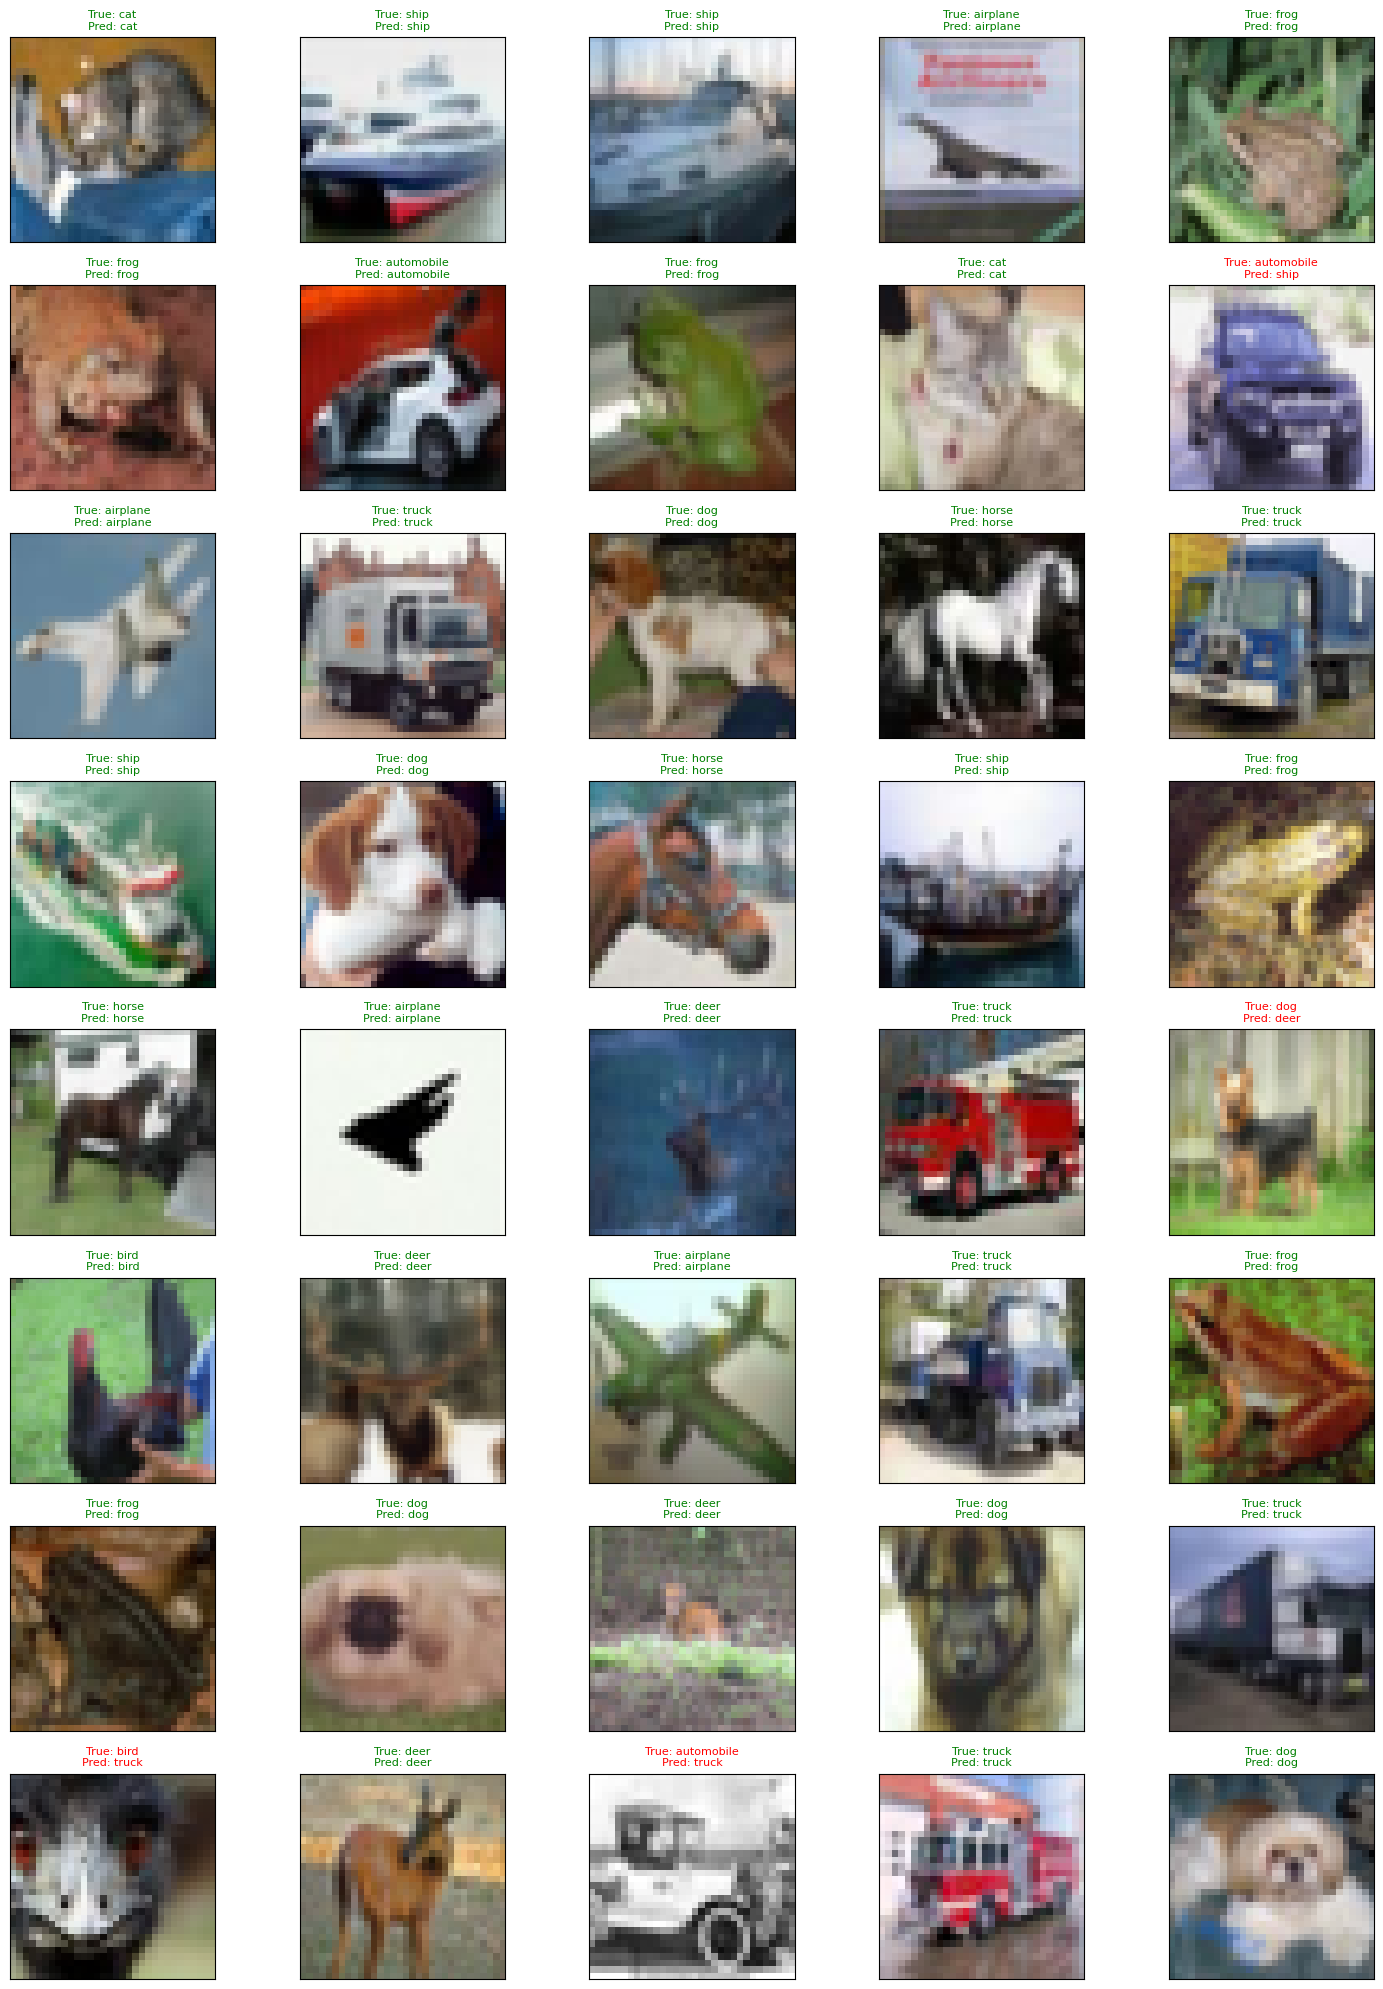

샘플 40개 중 정답: 36/40 (90.0%)


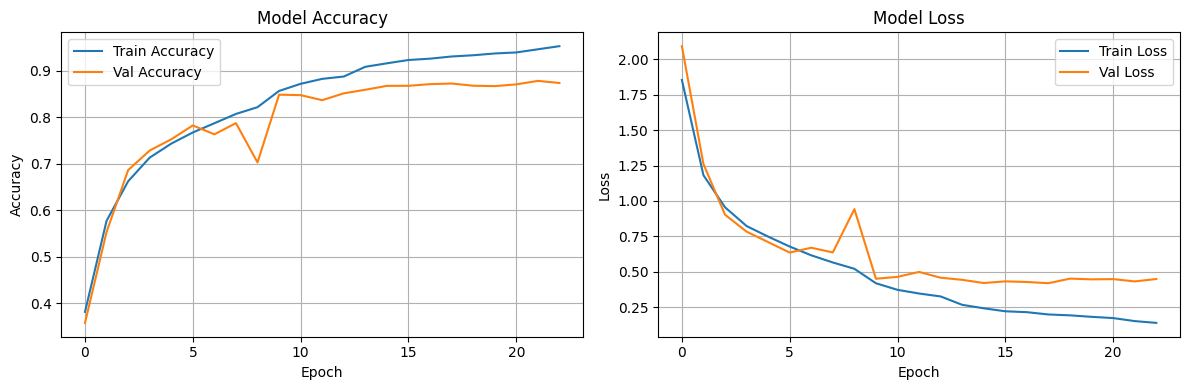

In [28]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"\n{'='*50}")
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")
print(f"{'='*50}\n")

prob = model.predict(x_test[0:40], verbose=0)
pred = tf.argmax(prob, axis=1)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig = plt.figure(figsize=(15, 20))
for i in range(40):
    subplot = fig.add_subplot(8, 5, i + 1)
    subplot.set_xticks([])
    subplot.set_yticks([])

    true_idx = tf.argmax(y_test[i]).numpy()
    pred_idx = pred[i].numpy()

    color = 'green' if true_idx == pred_idx else 'red'
    subplot.set_title(f'True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}',
                     color=color, fontsize=8)
    subplot.imshow(x_test[i])

plt.tight_layout()
plt.show()

# 정확도 통계
correct = sum([1 for i in range(40) if tf.argmax(y_test[i]).numpy() == pred[i].numpy()])
print(f"샘플 40개 중 정답: {correct}/40 ({correct/40*100:.1f}%)")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [29]:

print("Test Accuracy:", accuracy)


Test Accuracy: 0.8716999888420105
